# **Travail Pratique : Cohérence et visualisation des données**

## **Contexte et objectif**
Le travail pratique a pour objectif d'appliquer des techniques de nettoyage de données, de préparation et de visualisation sur un jeu de données fictives d'achat d'outils informatiques. Vous devrez identifier et corriger les anomalies, normaliser et standardiser les informations, puis visualiser les résultats.

## **Compétences et outils utilisés**
Ce travail pratique repose sur l'utilisation des outils et des méthodes présentés dans les **modules 4 et 5**, notamment :
- **Pandas** : pour la manipulation, la transformation et l'organisation des données sous forme de DataFrame.
- **Numpy** et **Scipy** : pour effectuer des calculs statistiques et numériques.
- **Scikit-learn** : pour les techniques avancées d'encodage d'apprentissage machine.
- **Seaborn** et **Matplotlib** : pour la visualisation graphique.

Notez que certaines notions des modules précédents pourront être nécessaires pour mener à bien le projet.

## **Livrables attendus**  

**Toutes les réponses doivent être rédigées directement dans ce notebook**. Le livrable final est un *fichier Jupyter Notebook* exécutable sur Google Colab **sans erreurs**.  

Pour chaque question, le notebook doit contenir :  

- **Une seule cellule de code** implémentant la solution :  
  - Le code doit être **clair et bien commenté** pour faciliter la compréhension.  
  - Une exception est faite pour l'installation des librairies ou le chargement des données : ces opérations peuvent être effectuées dans une **cellule indépendante**, sans nécessité d'explication.  

- **Une seule cellule de texte** expliquant la démarche :  
  - La méthodologie utilisée, les défis rencontrés et les solutions mises en place doivent être présentés de manière **claire et concise**.  
  - Chaque explication doit être **limitée à 10 lignes maximum** par cellule.  

L'objectif est de produire un **notebook structuré, lisible et facile à exécuter**.


## **Critères d'évaluation**  

### **1. Qualité du Code**  
- **Efficacité du nettoyage des données** : Vous devez démontrer une capacité à identifier et corriger correctement les anomalies dans les données, telles que les valeurs aberrantes et les erreurs de format. Cela inclut la normalisation des valeurs (comme les séparateurs numériques) et la gestion des erreurs (doublons, valeurs manquantes).

- **Organisation et nettoyage** : Les données doivent être organisées de manière logique et cohérente, facilitant l'accès et la manipulation pour l'analyse. La normalisation des formats (dates, montants, etc.) est essentielle pour garantir l'intégrité des données et leur préparation pour les étapes suivantes.

- **Visualisation et interprétation** : Les visualisations doivent être claires, pertinentes et bien étiquetées, permettant de mettre en évidence des tendances et anomalies dans les données. Les graphiques doivent être accompagnés d'interprétations détaillées pour expliquer les résultats obtenus, et les outils de visualisation comme Seaborn et Matplotlib doivent être utilisés de manière efficace pour illustrer les analyses.

### **2. Clarté et Lisibilité du Code**  
- Code **bien structuré**, avec une séparation logique des étapes.  
- **Présence de commentaires** expliquant les parties essentielles du code.  
- Nommage **clair et explicite** des variables et fonctions.  
- Utilisation des **bonnes pratiques de programmation** (éviter la duplication de code, modularité avec des fonctions).  

### **3. Explications et Justification des Choix**  
- Chaque question doit être accompagnée d'une **explication concise** de la méthodologie utilisée (10 lignes max par cellule).  
- Justification des choix techniques (ex. pourquoi utiliser une méthode de visualisation spécifique).  
- Discussion des défis rencontrés et des solutions adoptées pour les surmonter.  

### **4. Exécution et Fiabilité**  
- Le notebook **doit s'exécuter sans erreurs** sur **Google Colab**.  
- Gestion robuste des erreurs (ex. manipulation des formats, etc.).  
- Un **notebook propre et bien organisé**, sans cellules inutiles ou redondantes.  
- Respect des consignes du travail (structure demandée, formats de fichiers, etc.).  

---


# **Travail à réaliser**

Soit la base de données fictive contenue dans le fichier CSV à l'adresse [https://raw.githubusercontent.com/hgueziri/MiscData/refs/heads/main/donnees_achats_informatiques.csv](https://raw.githubusercontent.com/hgueziri/MiscData/refs/heads/main/donnees_achats_informatiques.csv).

La base de données contient des informations relatives à des achats effectués par des clients. Le tableau suivant donne une description des différentes colonnes ainsi que les erreurs possibles qui peuvent nécessiter un nettoyage :

| **Colonne**         | **Description**                                                                                   | **Problèmes possibles**                                                                                   |
|---------------------|---------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------------|
| **Client_ID**       | Identifiant unique du client. | Aucune erreur spécifique. |
| **Nom**             | Nom complet du client (prénom et nom de famille). | Erreurs typographiques et de formats. |
| **Age**             | Âge du client au moment de l'achat. | Valeurs aberrantes. |
| **Produit**  | Nom du produit acheté. | Aucune erreur spécifique. |
| **Montant**   | Montant total de l'achat. | Erreurs de formats et valeurs aberrantes. |
| **Date**      | Date de l'achat. | Erreurs de formats. |
| **Paiement**| Mode de paiement (carte_credit, virement_bancaire, PayPal, etc.). | Erreurs typographiques. |
| **Code_Barre**      | Code-barres unique du produit acheté. | Aucune erreur spécifique. |
| **SWIFT**           | Code SWIFT associé à la transaction bancaire. | Aucune erreur spécifique. |
| **Latitude**        | Latitude de l'adresse de livraison du client. | Valeurs aberrantes. |
| **Longitude**       | Longitude de l'adresse de livraison du client. | Valeurs aberrantes. |
| **Ville**           | Ville de l'adresse de livraison. | Aucune erreur spécifique. |
| **Pays**            | Pays de livraison. | Aucune erreur spécifique. |







In [ ]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/hgueziri/MiscData/refs/heads/main/donnees_achats_informatiques.csv', sep=';')
df.info()
df.head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Client_ID   10000 non-null  int64  
 1   Nom         10000 non-null  object 
 2   Age         10000 non-null  int64  
 3   Produit     10000 non-null  object 
 4   Montant     10000 non-null  object 
 5   Date        10000 non-null  object 
 6   Paiement    10000 non-null  object 
 7   Code_Barre  10000 non-null  int64  
 8   SWIFT       10000 non-null  object 
 9   Latitude    10000 non-null  float64
 10  Longitude   10000 non-null  float64
 11  Ville       10000 non-null  object 
 12  Pays        10000 non-null  object 
dtypes: float64(2), int64(3), object(8)
memory usage: 1015.8+ KB


,Client_ID,Nom,Age,Produit,Montant,Date,Paiement,Code_Barre,SWIFT,Latitude,Longitude,Ville,Pays
0,8433213,"Lavoie, Amélie",37,Chargeur Sans Fil,18.0,25/06/2020,carte de crédit,3890838637946,YZFWGB1V,43.86682,-79.26630,Markham,Canada
1,9511613,Martine Therrien,42,Télévision,"3881,80",2024-03-03,carte de crédit,7816184959316,VHYJGBFO,46.23899,-63.13414,Charlottetown,Canada
2,8752550,océane lamoureux,52,Webcam,321.2,2023-07-14,carte de crédit,1928327648356,HBZKGBZR,46.23899,-63.13414,Charlottetown,Canada
3,8537676,Catherine Bérubé,78,Clavier Bluetooth,92.4,07/11/2023,Credit Card,8496965328716,DEUFGB1E,45.44868,-324.22470,Pointe-Claire,Canada
4,8784803,sarah marcoux,23,Console de Jeu,120.4,04/10/2021,paypal,4627048281480,ELYFGB87,45.43341,-73.86586,Beaconsfield,Canada
5,8701541,"DROLET, HENRI",48,Console de Jeu,187.2,2022-12-07,carte de crédit,1171822782487,GRYXGBMTZX2,53.51684,-113.31870,Sherwood Park,Canada
6,8331502,"Martineau, Alain-Bertrand",65,Projecteur,587.4,2023-04-06,carte_credit,3105183473829,HZPZGB0MGG1,42.83340,-80.38297,Norfolk County,Canada
7,9701069,Hugues Gosselin,53,Imprimante,100.0,2020-12-25,virement_bancaire,7262473178102,CYHFGB05,225.80284,-73.58248,Sainte-Catherine,Canada
8,9026063,Dorothée Carrier-Denis,34,Enceinte Bluetooth,231.4,12/12/2024,paypal,8723430980507,SPQQGBKD,53.51684,-113.31870,Sherwood Park,Canada
9,8191366,Victor-Xavier Ouellet,33,Écouteurs,-484.00,15/03/2023,carte_credit,6998543534622,OKYCGBA3GE8,134.31921,-119.48568,Kelowna,Canada


## Question 1

**Normalisation des unités :** Normalisez les valeurs de la colonne `Montant`, qui peuvent utiliser différents séparateurs pour les milliers et les décimales. Deux types de notation sont couramment rencontrés :  

- La virgule `,` pour séparer les milliers et le point `.` pour indiquer les décimales : `123,456.78`, qui correspond à `123456.78`.  
- La virgule `,` pour indiquer les décimales : `123456,78`, qui correspond à `123456.78`.  

Toutes les valeurs doivent être converties dans un format uniforme où **les milliers ne sont pas séparés par une virgule** et **le point `.` est utilisé pour les décimales**, par exemple :  
```
123456.78
```




In [ ]:
## On ne s'occupe pas des valeurs aberantes, juste du format

for index, row in df.iterrows():
  #if contain . then remove ,
  if '.' in df.loc[index, 'Montant'] :
    df.loc[index, 'Montant'] = df.loc[index, 'Montant'].replace(',', '')
  #else replace , with .
  else :
    df.loc[index, 'Montant'] = df.loc[index, 'Montant'].replace(',', '.')
#transforme le type de donne pour etre manipulable plus facilement
df['Montant']=pd.to_numeric(df['Montant'])

df.info()
df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Client_ID   10000 non-null  int64  
 1   Nom         10000 non-null  object 
 2   Age         10000 non-null  int64  
 3   Produit     10000 non-null  object 
 4   Montant     10000 non-null  float64
 5   Date        10000 non-null  object 
 6   Paiement    10000 non-null  object 
 7   Code_Barre  10000 non-null  int64  
 8   SWIFT       10000 non-null  object 
 9   Latitude    10000 non-null  float64
 10  Longitude   10000 non-null  float64
 11  Ville       10000 non-null  object 
 12  Pays        10000 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 1015.8+ KB


,Client_ID,Nom,Age,Produit,Montant,Date,Paiement,Code_Barre,SWIFT,Latitude,Longitude,Ville,Pays
0,8433213,"Lavoie, Amélie",37,Chargeur Sans Fil,18.0,25/06/2020,carte de crédit,3890838637946,YZFWGB1V,43.86682,-79.26630,Markham,Canada
1,9511613,Martine Therrien,42,Télévision,3881.8,2024-03-03,carte de crédit,7816184959316,VHYJGBFO,46.23899,-63.13414,Charlottetown,Canada
2,8752550,océane lamoureux,52,Webcam,321.2,2023-07-14,carte de crédit,1928327648356,HBZKGBZR,46.23899,-63.13414,Charlottetown,Canada
3,8537676,Catherine Bérubé,78,Clavier Bluetooth,92.4,07/11/2023,Credit Card,8496965328716,DEUFGB1E,45.44868,-324.22470,Pointe-Claire,Canada
4,8784803,sarah marcoux,23,Console de Jeu,120.4,04/10/2021,paypal,4627048281480,ELYFGB87,45.43341,-73.86586,Beaconsfield,Canada
5,8701541,"DROLET, HENRI",48,Console de Jeu,187.2,2022-12-07,carte de crédit,1171822782487,GRYXGBMTZX2,53.51684,-113.31870,Sherwood Park,Canada
6,8331502,"Martineau, Alain-Bertrand",65,Projecteur,587.4,2023-04-06,carte_credit,3105183473829,HZPZGB0MGG1,42.83340,-80.38297,Norfolk County,Canada
7,9701069,Hugues Gosselin,53,Imprimante,100.0,2020-12-25,virement_bancaire,7262473178102,CYHFGB05,225.80284,-73.58248,Sainte-Catherine,Canada
8,9026063,Dorothée Carrier-Denis,34,Enceinte Bluetooth,231.4,12/12/2024,paypal,8723430980507,SPQQGBKD,53.51684,-113.31870,Sherwood Park,Canada
9,8191366,Victor-Xavier Ouellet,33,Écouteurs,-484.0,15/03/2023,carte_credit,6998543534622,OKYCGBA3GE8,134.31921,-119.48568,Kelowna,Canada


**Explication**

On traverse l'intégralité de la table. Si la str de Montant contient un ".", on a à faire au format 12,345.67, donc on retire la virgule afin d'atteindre le format rechercher de 12345.67. Si la str de Montant ne contient pas de ".", on peut prendre pour acquis qu'on a à faire à l'autre format : 12345,67. On peut donc uniquement remplacer la virgule par un point afin d'atteindre le format recherché de 12345.67. Finalement, on transforme le type de données de la colonne en float afin de pouvoir plus facilement les manipuler et les comparer dans le futur.

## Question 2

**Normalisation des chaînes de caractères :** Les noms et prénoms des clients dans la colonne `Nom` peuvent apparaître sous deux formats :  
- `Nom, Prénom`  
- `Prénom Nom`  

De plus, des espaces supplémentaires peuvent apparaître avant et après ces entrées. Normalisez la colonne `Nom` (prénom et nom de famille) en respectant les règles suivantes :  

- Le prénom doit apparaître en premier, suivi d'un espace, puis du nom de famille : `Prénom Nom_de_famille` (ex. `Maltais, Gérard` devient `Gérard Maltais`).  
- Les noms et prénoms composés doivent être conservés comme une seule entité, par exemple `Lemire-Gauthier` reste inchangé.  
- La capitalisation doit être correcte :  
  - La première lettre du prénom et du nom doit être en majuscule, ex. `Amélie` `Lavoie`.  
  - Si le nom ou le prénom est composé, chaque élément doit commencer par une majuscule, ex. `Lemire-Gauthier`.  
  - Toutes les autres lettres doivent être en minuscules.
- Aucun espace superflu ne doit être présent avant, après ou entre les noms et prénoms.



In [ ]:
## On prend pour acquis qu'on n'a pas de nom composer sans '-' (eg Pierre Elliot Gauthier)

for index, row in df.iterrows():
  #remove ' ' before and after
  df.loc[index, 'Nom'] = df.loc[index, 'Nom'].strip()
  #if contain , then split at , and asign prenom et nom
  if ',' in df.loc[index, 'Nom'] :
    [nom, prenom] = df.loc[index, 'Nom'].split(', ')
  #else split at ' ' and assign prenom et nom
  else :
    [prenom, nom] = df.loc[index, 'Nom'].split(' ')
  #reassemble as prenom+' '+nom and capitalize
  df.loc[index, 'Nom'] = prenom.title()+' '+nom.title()

df.head(20)

,Client_ID,Nom,Age,Produit,Montant,Date,Paiement,Code_Barre,SWIFT,Latitude,Longitude,Ville,Pays
0,8433213,Amélie Lavoie,37,Chargeur Sans Fil,18.0,25/06/2020,carte de crédit,3890838637946,YZFWGB1V,43.86682,-79.26630,Markham,Canada
1,9511613,Martine Therrien,42,Télévision,3881.8,2024-03-03,carte de crédit,7816184959316,VHYJGBFO,46.23899,-63.13414,Charlottetown,Canada
2,8752550,Océane Lamoureux,52,Webcam,321.2,2023-07-14,carte de crédit,1928327648356,HBZKGBZR,46.23899,-63.13414,Charlottetown,Canada
3,8537676,Catherine Bérubé,78,Clavier Bluetooth,92.4,07/11/2023,Credit Card,8496965328716,DEUFGB1E,45.44868,-324.22470,Pointe-Claire,Canada
4,8784803,Sarah Marcoux,23,Console de Jeu,120.4,04/10/2021,paypal,4627048281480,ELYFGB87,45.43341,-73.86586,Beaconsfield,Canada
5,8701541,Henri Drolet,48,Console de Jeu,187.2,2022-12-07,carte de crédit,1171822782487,GRYXGBMTZX2,53.51684,-113.31870,Sherwood Park,Canada
6,8331502,Alain-Bertrand Martineau,65,Projecteur,587.4,2023-04-06,carte_credit,3105183473829,HZPZGB0MGG1,42.83340,-80.38297,Norfolk County,Canada
7,9701069,Hugues Gosselin,53,Imprimante,100.0,2020-12-25,virement_bancaire,7262473178102,CYHFGB05,225.80284,-73.58248,Sainte-Catherine,Canada
8,9026063,Dorothée Carrier-Denis,34,Enceinte Bluetooth,231.4,12/12/2024,paypal,8723430980507,SPQQGBKD,53.51684,-113.31870,Sherwood Park,Canada
9,8191366,Victor-Xavier Ouellet,33,Écouteurs,-484.0,15/03/2023,carte_credit,6998543534622,OKYCGBA3GE8,134.31921,-119.48568,Kelowna,Canada


**Explication**

On prend pour acquis qu'on n'a pas de nom donc le format diffère de ceux présentés dans l'énoncé. On passe à travers l'intégralité de la table pour modifier les noms d'une entrée à la fois. On commence par retirer les espaces superflus avant et après les morceaux du nom avec la fonction strip(). Ensuite, si la str contient une virgule, on sait qu'on a à faire au format "Nom, Prenom", donc on divise la str au ", " avec la fonction split() et on assigne les parties aux variables nom et prenom associées. Si la str ne contient pas de virgule, on sait qu'on à au faire au format "Prénom Nom", donc on divise la str au " " avec la fonction split() et on associe les parties aux variables prénom et nom associées. Finalement, on réassemble les parties prénom et nom dans le format recherché, et on en profite pour forcer la capitalisation des noms attendue avec la fonction title().

## Question 3

**Normalisation des étiquettes :** Normalisez les valeurs de la colonne `Paiement` en regroupant les différentes variantes sous trois catégories distinctes :  

- **"Credit"** : inclut `"carte de crédit"`, `"Credit Card"` et `"carte_credit"`.  
- **"PayPal"** : inclut `"PayPal"` et `"paypal"`.  
- **"Virement"** : inclut `"Virement Bancaire"` et `"virement_bancaire"`.  

Après nettoyage, la colonne `Paiement` ne doit contenir que les étiquettes `"Credit"`, `"PayPal"` ou `"Virement"`.


In [ ]:
## On supposse que le df ne contient aucune autre variante que celles donnees ci-haut
import seaborn as sns
for index, row in df.iterrows():
  #lower case everything
  df.loc[index, 'Paiement'] = df.loc[index, 'Paiement'].lower()
  #replace é with e
  df.loc[index, 'Paiement'] = df.loc[index, 'Paiement'].replace('é', 'e')
  #if paiement contains credit replace with 'Credit
  if 'credit' in df.loc[index, 'Paiement'] :
    df.loc[index, 'Paiement'] = 'Credit'
  #elif paiement contains paypal replace with PayPal
  elif 'paypal' in df.loc[index, 'Paiement'] :
    df.loc[index, 'Paiement'] = 'PayPal'
  #elif paiement contains virement replace with 'Virement'
  elif 'virement' in df.loc[index, 'Paiement'] :
    df.loc[index, 'Paiement'] = 'Virement'

#s'assure qu'on a pas rate d'entree dans la reformatation
#sns.countplot(data=df, x="Paiement", order=df["Paiement"].value_counts().index)
df.head(20)

,Client_ID,Nom,Age,Produit,Montant,Date,Paiement,Code_Barre,SWIFT,Latitude,Longitude,Ville,Pays
0,8433213,Amélie Lavoie,37,Chargeur Sans Fil,18.0,25/06/2020,Credit,3890838637946,YZFWGB1V,43.86682,-79.26630,Markham,Canada
1,9511613,Martine Therrien,42,Télévision,3881.8,2024-03-03,Credit,7816184959316,VHYJGBFO,46.23899,-63.13414,Charlottetown,Canada
2,8752550,Océane Lamoureux,52,Webcam,321.2,2023-07-14,Credit,1928327648356,HBZKGBZR,46.23899,-63.13414,Charlottetown,Canada
3,8537676,Catherine Bérubé,78,Clavier Bluetooth,92.4,07/11/2023,Credit,8496965328716,DEUFGB1E,45.44868,-324.22470,Pointe-Claire,Canada
4,8784803,Sarah Marcoux,23,Console de Jeu,120.4,04/10/2021,PayPal,4627048281480,ELYFGB87,45.43341,-73.86586,Beaconsfield,Canada
5,8701541,Henri Drolet,48,Console de Jeu,187.2,2022-12-07,Credit,1171822782487,GRYXGBMTZX2,53.51684,-113.31870,Sherwood Park,Canada
6,8331502,Alain-Bertrand Martineau,65,Projecteur,587.4,2023-04-06,Credit,3105183473829,HZPZGB0MGG1,42.83340,-80.38297,Norfolk County,Canada
7,9701069,Hugues Gosselin,53,Imprimante,100.0,2020-12-25,Virement,7262473178102,CYHFGB05,225.80284,-73.58248,Sainte-Catherine,Canada
8,9026063,Dorothée Carrier-Denis,34,Enceinte Bluetooth,231.4,12/12/2024,PayPal,8723430980507,SPQQGBKD,53.51684,-113.31870,Sherwood Park,Canada
9,8191366,Victor-Xavier Ouellet,33,Écouteurs,-484.0,15/03/2023,Credit,6998543534622,OKYCGBA3GE8,134.31921,-119.48568,Kelowna,Canada


**Explication**

On commence par mettre toutes les valeurs de la colonne Paiement en minuscule et on remplace tous les "é" par des "e" afin de pouvoir plus facilement identifier les valeurs pour les remplacer, au lieu de devoir les comparer à toutes les orthographes et capitalisations possibles. Ensuite, on passe à travers toutes les entrées, et si la valeur de Paiement contient "credit", on la remplace par la valeur "Credit" attendue; si elle contient "paypal", on la remplace par la valeur "PayPal" attendue; et si elle contient "virement", on la remplace par la valeur "Virement" attendue. On peut ensuite utiliser le code laissé en commentaire pour s'assurer qu'on n'a pas raté de valeur lors du reformatage.

## Question 4

**Détection et gestion des valeurs aberrantes :** Identifiez les valeurs aberrantes dans les colonnes suivantes : `Age`, `Montant`, `Latitude` et `Longitude`.
   - Utilisez les méthodes de détection adaptées à chaque colonne.
   - Utilisez une méthode de visualisation appropriée pour mettre en évidence les valeurs aberrantes de chaque colonne.
   - Proposez des stratégies pour gérer ces valeurs aberrantes (ex. suppression, remplacement par des valeurs moyennes/medians).



<Axes: xlabel='Age', ylabel='Count'>

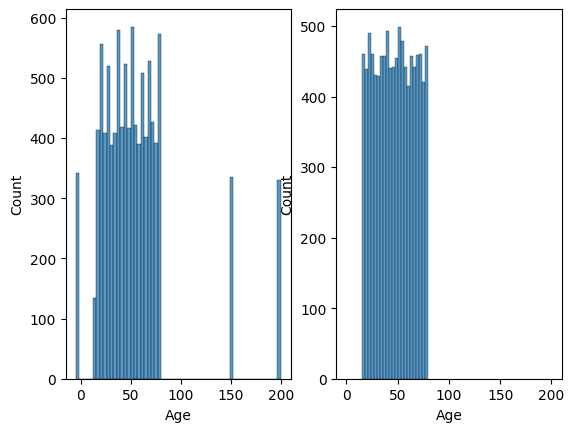

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#si on observe les valeurs non-aberrantes, on a l'air d'avoir une distribution uniforme
plt.subplot(1,2,1)
sns.histplot(data=df, x="Age")
#L'age doit etre une valeur positive non-nulle (donc >0), et on peut voir qu'il n'y a pas de valeur non-aberante plus grande que 100, donc on met la limite superieur de l'age a 100 (meme s'il existe des humains qui ont vecu jusqu'a plus de 100 ans)
valid_age=df['Age'][(df['Age']>0) & (df['Age']<=100)]
for index, row in df.iterrows():
  #si la valeur est a l'exterieur des limites [0,100], on la remplace par une valeur au hasard dans la distribution uniforme de l'intervale valide qui existe deja
  if df.loc[index, 'Age']<=0 or df.loc[index, 'Age']>100 :
    df.loc[index, 'Age'] = np.floor(np.random.uniform(valid_age.min(),valid_age.max()))
#verifie qu'on a pas de valeurs aberrantes non-gerees
plt.subplot(1,2,2)
plt.xlim(-10,210)
sns.histplot(data=df, x="Age")

<Axes: xlabel='Montant', ylabel='Count'>

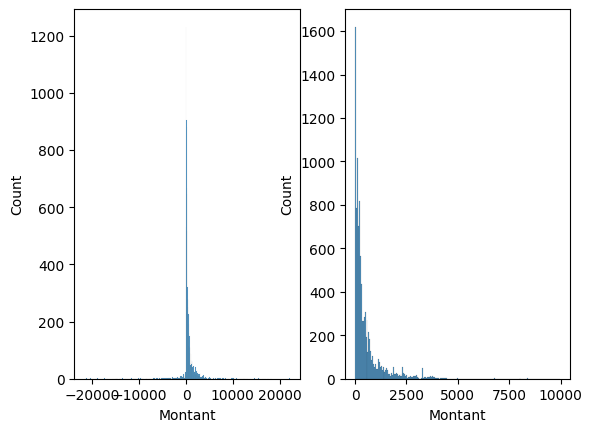

In [ ]:

#on observe les valeurs aberrantes
plt.subplot(1,2,1)
sns.histplot(data=df, x="Montant")
#on exclu les valeurs invalides <=0
valid_montant=df[['Montant', 'Produit']][df['Montant']>0]
#on calcule les moyennes et les ecart-types pour tous les produits
products_stats_means=valid_montant.groupby(by='Produit')['Montant'].mean()
products_stats_std=valid_montant.groupby(by='Produit')['Montant'].std()
for index, row in df.iterrows():
  #si le montant est nulle ou negatif, ou qu'il est a plus de 3 ecart-types de la valeur moyenne de ce produit
  if df.loc[index, 'Montant']<=0 or df.loc[index, 'Montant']<products_stats_means[df.loc[index, 'Produit']]-3*products_stats_std[df.loc[index, 'Produit']] or df.loc[index, 'Montant']>products_stats_means[df.loc[index, 'Produit']]+3*products_stats_std[df.loc[index, 'Produit']]:
    df.loc[index, 'Montant']=products_stats_means[df.loc[index, 'Produit']]
#verifie qu'on a pas de valeurs aberrantes non-gerees
plt.subplot(1,2,2)
sns.histplot(data=df, x="Montant")


<Axes: xlabel='Longitude', ylabel='Count'>

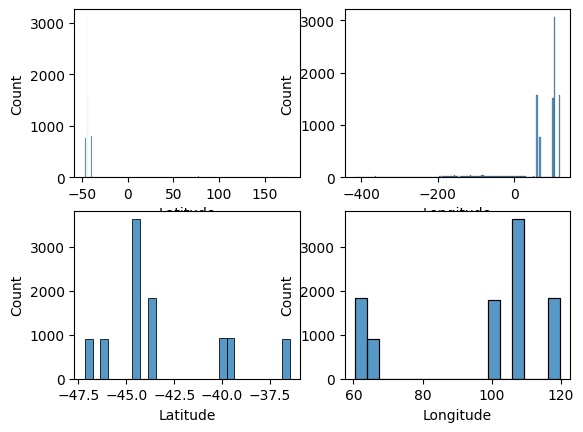

In [ ]:
## La latitude est sensee etre une valeur entre -90 et 90, et la longitude entre -180 et 180, donc on ajuste les distributions pour etre dans ces intervalles.
df['Latitude']=df['Latitude']-90
df['Longitude']=df['Longitude']+180
#on observe les valeurs aberrantes a l'exterieur des bornes +/-90 et +/-180
plt.subplot(2,2,1)
sns.histplot(data=df, x="Latitude")
plt.subplot(2,2,2)
sns.histplot(data=df, x="Longitude")
#cree une table qui assigne a chaque ville la latitude/longitude qui lui est le plus associe dans df
ville_lat_brut=df[['Pays', 'Ville', 'Latitude']]
ville_lat=ville_lat_brut.groupby(by=['Pays', 'Ville'], group_keys=False)['Latitude'].apply(lambda x: x.mode().iloc[0])
ville_long_brut=df[['Pays', 'Ville', 'Longitude']]
ville_long=ville_long_brut.groupby(by=['Pays','Ville'], group_keys=False)['Longitude'].apply(lambda x: x.mode().iloc[0])
for index, row in df.iterrows():
  #si la latitude est plus de 1 degree de difference par rapport a la latitude de sa ville, elle est erronee, on la remplace par la latitude de sa ville
  if df.loc[index, 'Latitude']<ville_lat[df.loc[index, 'Pays'], df.loc[index, 'Ville']]-1 or df.loc[index, 'Latitude']>ville_lat[df.loc[index, 'Pays'], df.loc[index, 'Ville']]+1 :
    df.loc[index, 'Latitude']=ville_lat[df.loc[index, 'Pays'], df.loc[index, 'Ville']]
  #si la longitude est plus de 1 degree de difference par rapport a la longitude de sa ville, elle est erronee, on la remplace par la longitude de sa ville
  if df.loc[index, 'Longitude']<ville_long[df.loc[index, 'Pays'], df.loc[index, 'Ville']]-1 or df.loc[index, 'Longitude']>ville_long[df.loc[index, 'Pays'], df.loc[index, 'Ville']]+1 :
    df.loc[index, 'Longitude']=ville_long[df.loc[index, 'Pays'], df.loc[index, 'Ville']]
#verifie qu'on a pas de valeurs aberrantes non-gerees
plt.subplot(2,2,3)
sns.histplot(data=df, x="Latitude")
plt.subplot(2,2,4)
sns.histplot(data=df, x="Longitude")


**Explication**

Si on regarde la distribution de l'âge, on remarque qu'elle a l'air d'une distribution uniforme, si on omet les valeurs aberrantes. Ces valeurs sont celles négatives ou nulles, puisqu'il est impossible qu'un âge soit négatif ou nul, ainsi que celles de plus de 100, puisqu'il est très peu probable que quelqu'un de plus de 100 ans fasse un achat de produit électronique, et les humains qui survivent jusqu'a cet âge sont très rares. Pour les valeurs à l'extérieur de ces balises, on les remplace par une valeur aléatoire de la distribution formée par les valeurs non aberrantes, afin de pouvoir garder leur enregistrement. Le fait d'assigner une valeur aléatoire à ces entrées pourrait causer du bruit sur les analyses comparatives qu'on voudrait faire entre l'âge et une autre variable, mais considérant la quantité de valeurs aberrantes par rapport à la quantité de valeurs attendues, ce n'est pas une quantité de bruit significative.

Pour la distribution des montants payés, on se base sur le produit vendu pour déterminer quel genre de valeurs sont attendues. On considère aberrantes toutes les valeurs négatives et nulles puisqu'il n'est pas possible de payer un montant négatif ou nul. De plus, toutes les valeurs étant à plus de 3 écarts-types de la valeur moyenne de leur produit sont aussi considérées aberrantes. Cependant, on n'applique pas de limite maximale formelle au montant puisqu'il est possible de payer plusieurs milliers de dollars pour de l'équipement électronique. Lors des calculs pour ces moyennes et écarts-types, on n'utilise que les valeurs strictement positives, pour ne pas que les mesures soient affecté par de valeurs qu'on sait aberrantes. Les valeurs à l'extérieur de ces balises sont donc remplacées par la valeur moyenne du produit qui a été vendue. Le remplacement par ces valeurs permet à la distribution de rester fidèle à sa forme, ainsi que de permettre une analyse de prix pour chaque produit plus exacte que si on avait pris des valeurs au hasard dans la distribution. Cependant, en remplaçant les valeurs par leur moyenne, on court le risque de perdre des valeurs correctes extrêmes qui reflètent des scénarios inhabituels (eg: éditions spéciales, rabais de fin d'années, etc.)

Finalement, pour la latitude et la longitude, on commence par normaliser les valeurs afin qu'elles soient dans les balises attendues pour des latitudes (+/-90 degrés) et des longitudes (+/-180 degrés). Ensuite, on battit des tables temporaires qui associent à chaque couple (pays, ville) présent dans la table originale la latitude et la longitude les plus souvent associées à ce couple. De ce fait, on trouve la longitude et la latitude de toutes les villes de livraison dans la table de donnée. Puisque toutes les adresses de livraison dans une ville devraient être à +/-1 degré des coordonnées de la ville en entier, on considère toutes les coordonnées à l'extérieur de cet écart comme des données aberrantes. Donc, on remplace les valeurs de latitude et longitude de toutes les entrées à l'extérieur des valeurs permises pour celles associées à leur ville dans les tables temporaires.

## Question 5

**Standardisation des labels :**  
- Transformez la colonne `Paiement` en plusieurs colonnes binaires, une pour chaque type de paiement.  
- Chaque nouvelle colonne correspond à un mode de paiement unique (ex. `Credit`, `PayPal`, `Virement`).  
- Assignez la valeur `1` si la transaction a été effectuée avec ce mode de paiement, sinon assignez `0`.  
- Supprimez la colonne originale `Paiement` après la transformation.  

Exemple de transformation :  

| Paiement         | Credit | PayPal | Virement |  
|-----------------|--------|--------|----------|  
| Credit Card     | 1      | 0      | 0        |  
| PayPal         | 0      | 1      | 0        |  
| Virement Bancaire | 0      | 0      | 1        |  



In [ ]:
df['Credit']=df['Paiement'].apply(lambda x: 1 if x=='Credit' else 0)
df['PayPal']=df['Paiement'].apply(lambda x: 1 if x=='PayPal' else 0)
df['Virement']=df['Paiement'].apply(lambda x: 1 if x=='Virement' else 0)
df.drop(columns=['Paiement'], inplace=True)
df.head(20)


,Client_ID,Nom,Age,Produit,Montant,Date,Code_Barre,SWIFT,Latitude,Longitude,Ville,Pays,Credit,PayPal,Virement
0,8433213,Amélie Lavoie,37,Chargeur Sans Fil,18.000000,25/06/2020,3890838637946,YZFWGB1V,-46.13318,100.73370,Markham,Canada,1,0,0
1,9511613,Martine Therrien,42,Télévision,3881.800000,2024-03-03,7816184959316,VHYJGBFO,-43.76101,116.86586,Charlottetown,Canada,1,0,0
2,8752550,Océane Lamoureux,52,Webcam,321.200000,2023-07-14,1928327648356,HBZKGBZR,-43.76101,116.86586,Charlottetown,Canada,1,0,0
3,8537676,Catherine Bérubé,78,Clavier Bluetooth,92.400000,07/11/2023,8496965328716,DEUFGB1E,-44.55132,106.18331,Pointe-Claire,Canada,1,0,0
4,8784803,Sarah Marcoux,23,Console de Jeu,120.400000,04/10/2021,4627048281480,ELYFGB87,-44.56659,106.13414,Beaconsfield,Canada,0,1,0
5,8701541,Henri Drolet,48,Console de Jeu,187.200000,2022-12-07,1171822782487,GRYXGBMTZX2,-36.48316,66.68130,Sherwood Park,Canada,1,0,0
6,8331502,Alain-Bertrand Martineau,65,Projecteur,587.400000,2023-04-06,3105183473829,HZPZGB0MGG1,-47.16660,99.61703,Norfolk County,Canada,1,0,0
7,9701069,Hugues Gosselin,53,Imprimante,100.000000,2020-12-25,7262473178102,CYHFGB05,-44.59992,106.41752,Sainte-Catherine,Canada,0,0,1
8,9026063,Dorothée Carrier-Denis,34,Enceinte Bluetooth,231.400000,12/12/2024,8723430980507,SPQQGBKD,-36.48316,66.68130,Sherwood Park,Canada,0,1,0
9,8191366,Victor-Xavier Ouellet,33,Écouteurs,110.331118,15/03/2023,6998543534622,OKYCGBA3GE8,-40.11693,60.51432,Kelowna,Canada,1,0,0


**Explication**

Pour chacune des valeurs possibles pour la colonne Paiement, on applique la règle tel que la valeur dans la colonne de ce mode est 1 si la valeur de la colonne paiement est ce mode, sinon la valeur de la colonne de ce mode est 0. Ensuite, on retire la colonne Paiement avec la fonction drop().

## Question 6.1

- Créez un graphique de distribution des `Montant` en fonction de la méthode de `Paiement`.



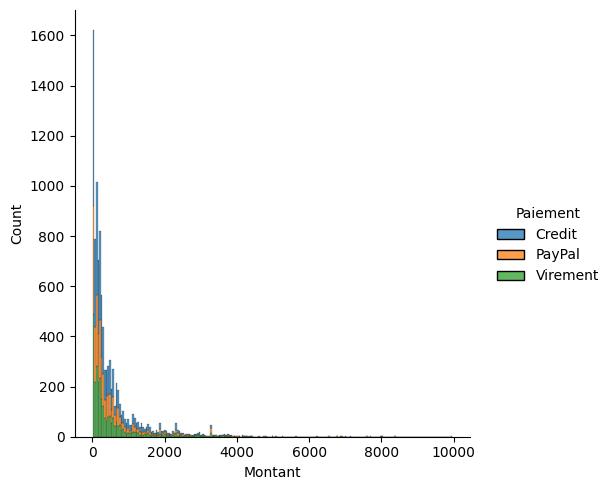

In [ ]:
#on reconstitue la colonne paiment dans une table temporaire
df_paiement=df.loc[:, ['Montant', 'Credit', 'PayPal', 'Virement']]
for index, row in df_paiement.iterrows():
  if df_paiement['Credit'][index]==1 :
    df_paiement.loc[index, 'Paiement']='Credit'
  elif df_paiement['PayPal'][index]==1 :
    df_paiement.loc[index, 'Paiement']='PayPal'
  elif df_paiement['Virement'][index]==1 :
    df_paiement.loc[index, 'Paiement']='Virement'
df_paiement.drop(columns=['Credit', 'PayPal', 'Virement'], inplace=True)
sns.displot(data=df_paiement, x="Montant", hue='Paiement', multiple="stack")

**Explication**

Il est plus facile de reconstituer la colonne Paiement à partir des colonnes Credit, PayPal et Virement afin de l'utiliser comme hue dans un histogramme de distribution que de manipuler les trois colonnes pour les associer dans le graphique en tant que tel. Une fois la colonne Paiement reconstituée dans la table temporaire, on retire les colonnes binaires de la table temporaire puis on utilise cette table pour afficher l'histogramme de distribution.

## Question 6.2

- Produire des graphiques afin de visualiser la relation enter les montants des achats `Montant` et la date d'achat `Date`. Existe-t-il un effet de corrélation ?



/tmp/ipython-input-1261561253.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


<Axes: xlabel='Date', ylabel='Montant'>

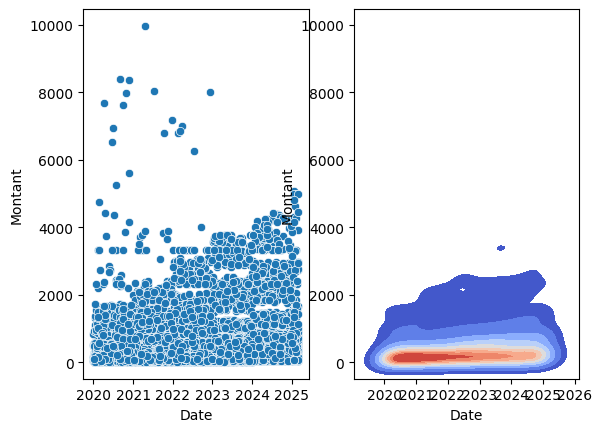

In [ ]:
#on normalise les dates sous format dd/mm/yyy
if not df['Date'].dtype.kind == 'M' :
  for index, row in df.iterrows():
    if '/' not in df.loc[index, 'Date'] :
      [year, month, date] = df.loc[index, 'Date'].split('-')
      df.loc[index, 'Date'] = date+'/'+month+'/'+year
  df['Date'] = pd.to_datetime(df['Date'])

plt.subplot(1,2,1)
sns.scatterplot(data=df, x="Date", y="Montant")
plt.subplot(1,2,2)
sns.kdeplot(data=df, x="Date", y="Montant", cmap='coolwarm', fill=True)


**Explication**

On commence par normaliser le format des dates afin de pouvoir les utiliser dans les graphiques d'analyse. Dans le premier graphique, on remarque que la majorité des points était concentré sous les 2000\$ en 2020, avec quelques points plus hauts sur l'échelle des montants possibles, mais qu'avec le temps, la concentration de point s'est diffusée jusqu'au 5000\$ graduellement, et les points disparates à l'extérieur de cette concentration ont à toute fin disparu. Cette analyse est corroborée par le graphique 2, ou on remarque une très forte concentration près de 0 en 2020 qui se diffuse progressivement jusqu'en 2025 pour représenter la quantité d'entrées qui sont maintenant plus haut dans l'échelle de montant possible. Bref, on observe que les prix des produits achetés ont augmenté avec le temps, passant de presque tout étant à moins de 2000\$ à un large étendue de prix allant jusqu'à 5000\$. On pourrait justifier cette fluctuation sur l'inflation et la pandémie, donc il est logique de penser qu'il y a une corrélation.

## Question 6.3
- Créez un graphique pour visualiser la répartition des `Latitude` et `Longitude` des clients. Qu'observez-vous ?

<Axes: xlabel='Longitude', ylabel='Count'>

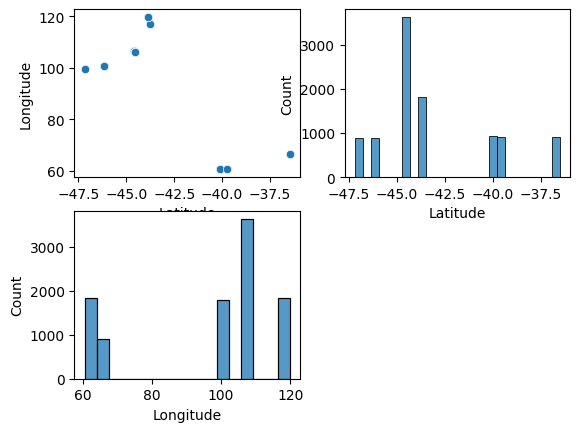

In [ ]:
plt.subplot(2,2,1)
sns.scatterplot(data=df, x="Latitude", y="Longitude")
plt.subplot(2,2,2)
sns.histplot(data=df, x="Latitude")
plt.subplot(2,2,3)
sns.histplot(data=df, x="Longitude")

**Explication**

À cause des manipulations qu'on a effectuées à la question 4.1, on se retrouve avec un très petit nombre de valeurs possibles pour les latitudes et les longitudes. Ceci est complètement logique puisque les entrées dans la table de données sont limitées à 11 villes canadiennes, donc il est normal que les couples (Latitude, Longitude) du graphique 1 soient concentrés sur les points représentant les coordonnées de ces villes. De plus, certaines villes, comme Pointe-Claire et Beaconsfield, sont voisins immédiats, donc leurs coordonnées n'ont même pas un degré de différence entre elles, donc elles ont l'air d'un seul point sur le graphique 1, même si ce sont deux valeurs distinctes. C'est pour cette raison qu'on dirait qu'il n'y a que huit concentrations de points sur le graphique 1, même si on sait que l’on compte 11 villes possibles dans la table.

Si les entrées comptaient un plus grand nombre de villes dispersées sur la planète, on aurait plus de points visibles sur le graphique 1 et un plus grand écart de valeurs possible dans les histogrammes de distribution des graphiques 2 et 3. De plus, si on n'avait pas accès aux villes et pays de livraison auxquels comparer les coordonnées, on aurait plus de valeurs erronées dans le graphique 1, c'est-à-dire des points plus dispersés.